In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import make_blobs
%matplotlib inline

In [3]:
X,Y=make_blobs(n_samples=1000, centers=3, n_features=2, random_state=23)

In [4]:
X.shape

(1000, 2)

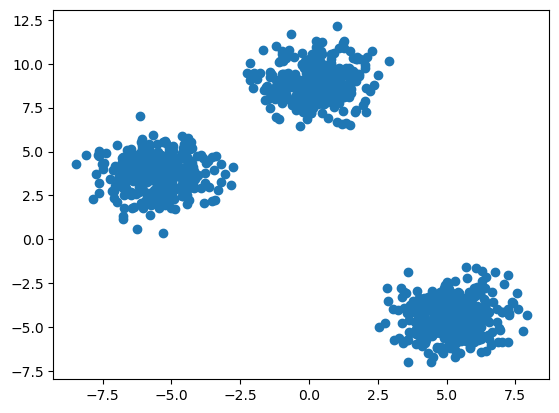

In [11]:
plt.scatter(X[:,0],X[:,1])
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.33, random_state=42)

In [14]:
from sklearn.cluster import KMeans

In [20]:
# manual processing 
# elbow method to select the k value 

wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)
    


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

In [22]:
wcss

[34827.57682552022,
 7935.4372861454185,
 1319.2730531585607,
 1140.467788465513,
 1004.3472124529277,
 948.1888494089358,
 762.7898468802294,
 732.5767516206412,
 618.7997803601484,
 537.8336756397441]

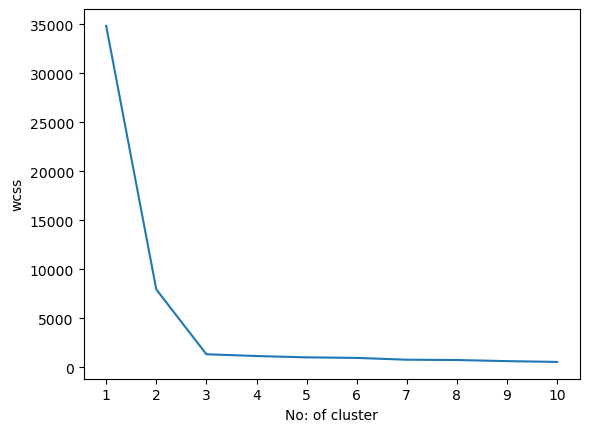

In [23]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("No: of cluster")
plt.ylabel("wcss")
plt.show()

In [33]:
kmeans=KMeans(n_clusters=3,init='k-means++')

In [34]:
Y_labels=kmeans.fit_predict(X_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [38]:
Y_test_label=kmeans.predict(X_test)

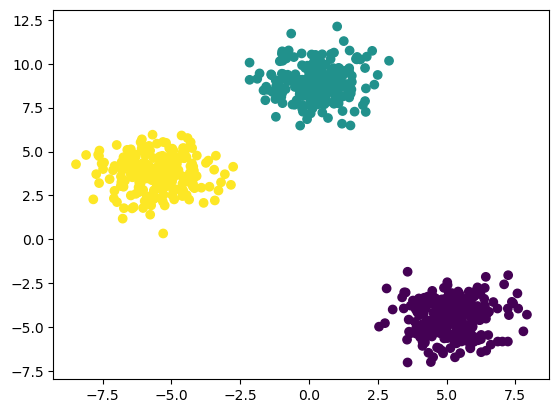

In [39]:
plt.scatter(X_train[:,0],X_train[:,1],c=Y_labels)
plt.show()

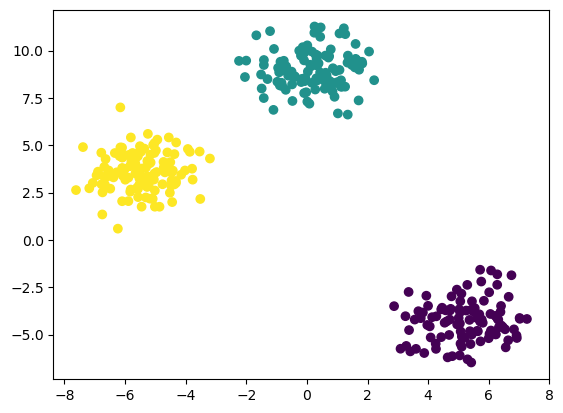

In [41]:
plt.scatter(X_test[:,0],X_test[:,1],c=Y_test_label)
plt.show()

In [43]:
#knee locater
!pip install kneed

In [47]:
from kneed import KneeLocator

In [52]:
kl=KneeLocator(range(1,11),wcss, curve='convex', direction='decreasing')

In [53]:
kl.elbow

3

In [54]:
# performance silhoute score
from sklearn.metrics import silhouette_score

In [58]:
silhouette_coefficients = [] 
for i in range(2,11):
    kmeans=KMeans(n_clusters=i,init='k-means++')
    kmeans.fit(X_train)
    score=silhouette_score(X_train, kmeans.labels_)
    silhouette_coefficients.append(score)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

In [59]:
silhouette_coefficients

[0.7281443868598331,
 0.8071181203797672,
 0.6426100715879455,
 0.47302263229328617,
 0.3378115746857066,
 0.33904853144025404,
 0.3331388399929889,
 0.34437036986683633,
 0.3410687037453126]

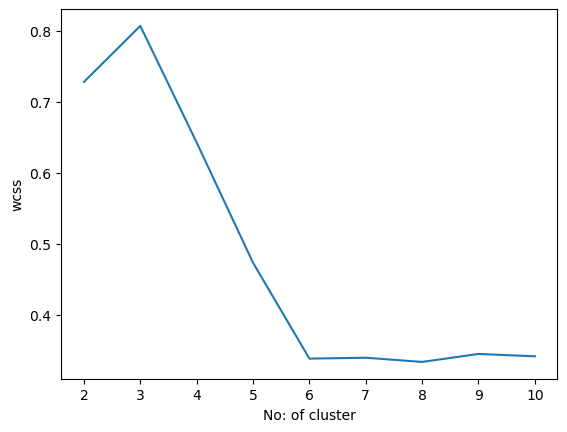

In [62]:
plt.plot(range(2,11), silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("No: of cluster")
plt.ylabel("wcss")
plt.show()